# Meteorite Landings — Exploratory Data Analysis (EDA)

**What this notebook does**

This notebook performs a complete EDA on the public **Meteorite Landings** dataset (the Meteoritical Society / NASA dataset). It follows the assignment steps: loading, inspecting, cleaning, analysis, visualizations, and an optional interactive map.

**Important:** the dataset is available from NASA's data portal (Socrata) at `https://data.nasa.gov/resource/y77d-th95.csv` or via the NASA dataset landing page. If your environment blocks direct internet access, download the CSV manually and place it next to this notebook (filename: `meteorite_landings.csv`).

---

> Notebook saved to `/mnt/data/meteorite_eda_notebook.ipynb`. Run this notebook in Jupyter or Colab. The cells include clear markdown explanations and all required steps for the assignment.

In [2]:
# Step 1: Setup - imports and helper functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Make plots render nicely
%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)
sns.set(style='whitegrid')

# Helper: safe parse year
def safe_parse_year(val):
    try:
        if pd.isnull(val):
            return np.nan
        if isinstance(val, (int, float)):
            return int(val)
        s = str(val)
        import re
        m = re.search(r'(\d{4})', s)
        if m:
            return int(m.group(1))
        return np.nan
    except Exception:
        return np.nan


In [3]:
# Step 1: Load the CSV into a DataFrame
# Option A (recommended): load directly from NASA Socrata API (requires internet)
url = 'meteorite_landings.csv'
try:
    df = pd.read_csv(url)
    print('Loaded dataset from NASA Socrata API (y77d-th95).')
except Exception as e:
    print('Could not load from URL — trying local file meteorite_landings.csv. Error:', e)
    df = pd.read_csv('meteorite_landings.csv')
    print('Loaded dataset from local file meteorite_landings.csv')

# Quick peek
print('\nShape:', df.shape)
df.head()


Loaded dataset from NASA Socrata API (y77d-th95).

Shape: (45716, 8)


,Name,ID,NameType,Classification,Mass,Fall,Year,Coordinates
0,Aachen,1,Valid,L5,"Quantity[21, ""Grams""]",Fell,"DateObject[{1880}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{50.775, 6.08333}]"
1,Aarhus,2,Valid,H6,"Quantity[720, ""Grams""]",Fell,"DateObject[{1951}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{56.18333, 10.23333}]"
2,Abee,6,Valid,EH4,"Quantity[107000, ""Grams""]",Fell,"DateObject[{1952}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{54.21667, -113.}]"
3,Acapulco,10,Valid,Acapulcoite,"Quantity[1914, ""Grams""]",Fell,"DateObject[{1976}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{16.88333, -99.9}]"
4,Achiras,370,Valid,L6,"Quantity[780, ""Grams""]",Fell,"DateObject[{1902}, ""Year"", ""Gregorian"", -5.]","GeoPosition[{-33.16667, -64.95}]"


In [7]:
# Inspecting the data
print('\n--- .info() ---')
df.info()
if 'Coordinates' in df.columns:
    print("  Parsing 'Coordinates' column...")
    coord_data = df['Coordinates'].dropna()
    if len(coord_data) > 0:
        # Try common formats: "lat, long", "lat:long", or space-separated
        df['Coordinates'] = df['Coordinates'].astype(str).str.replace(' ', '')  # Remove spaces
        coords_split = df['Coordinates'].str.split(r'[,:]', expand=True)
        if len(coords_split.columns) >= 2:
            df['reclat'] = pd.to_numeric(coords_split[0], errors='coerce')
            df['reclong'] = pd.to_numeric(coords_split[1], errors='coerce')
            print(f"  Parsed {len(df.dropna(subset=['reclat', 'reclong']))} rows with coordinates")
        else:
            print("  ⚠️  Could not parse 'Coordinates' format. Provide sample values for fix.")
    df = df.drop('Coordinates', axis=1)
else:
    print("  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist")

# We'll focus statistics on mass (g), year, latitude, longitude if present
for col in ['mass','mass_g','year','reclat','reclong','latitude','longitude']:
    if col in df.columns:
        print('\n--- describe for', col, '---')
        display(df[col].describe())
df_raw = pd.read_csv("meteorite_landings.csv")
df_raw['Coordinates'].dropna().head(10)


--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45716 entries, 0 to 45715
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            45716 non-null  object 
 1   id              45716 non-null  int64  
 2   nametype        45716 non-null  object 
 3   classification  45716 non-null  object 
 4   mass            45716 non-null  object 
 5   fall            45716 non-null  object 
 6   year            45716 non-null  object 
 7   reclat          0 non-null      float64
 8   reclong         0 non-null      float64
 9   mass_value      45585 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 3.5+ MB
  No 'Coordinates' column; assuming 'reclat' and 'reclong' exist

--- describe for mass ---


count                      45716
unique                     12577
top       Quantity[1.3, "Grams"]
freq                         171
Name: mass, dtype: object


--- describe for year ---


count                                            45716
unique                                             265
top       DateObject[{2003}, "Year", "Gregorian", -5.]
freq                                              3323
Name: year, dtype: object


--- describe for reclat ---


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: reclat, dtype: float64


--- describe for reclong ---


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: reclong, dtype: float64

0       GeoPosition[{50.775, 6.08333}]
1    GeoPosition[{56.18333, 10.23333}]
2       GeoPosition[{54.21667, -113.}]
3       GeoPosition[{16.88333, -99.9}]
4     GeoPosition[{-33.16667, -64.95}]
5            GeoPosition[{32.1, 71.8}]
6    GeoPosition[{44.83333, 95.16667}]
7     GeoPosition[{44.21667, 0.61667}]
8      GeoPosition[{-31.6, -65.23333}]
9     GeoPosition[{-30.86667, -64.55}]
Name: Coordinates, dtype: object

In [9]:
df_raw = pd.read_csv("meteorite_landings.csv")
df_raw['Coordinates'].dropna().head(10)

0       GeoPosition[{50.775, 6.08333}]
1    GeoPosition[{56.18333, 10.23333}]
2       GeoPosition[{54.21667, -113.}]
3       GeoPosition[{16.88333, -99.9}]
4     GeoPosition[{-33.16667, -64.95}]
5            GeoPosition[{32.1, 71.8}]
6    GeoPosition[{44.83333, 95.16667}]
7     GeoPosition[{44.21667, 0.61667}]
8      GeoPosition[{-31.6, -65.23333}]
9     GeoPosition[{-30.86667, -64.55}]
Name: Coordinates, dtype: object

In [50]:
# Step 2: Cleaning and preparation
# Standardize column names to lowercase
df.columns = [c.strip().lower() for c in df.columns]

# Extract numeric mass from "Quantity[...]"
df["mass_value"] = pd.to_numeric(
    df["mass"].str.extract(r"Quantity\[(\d+\.?\d*),")[0], 
    errors="coerce"
)

# Create mass_kg column from the numeric mass_value
df['mass_kg'] = df['mass_value'] / 1000.0  # grams → kilograms

# Optional: drop mass_value if you don't need it
# df = df.drop(columns=['mass_value'])

# Filter rows with positive mass
df_valid = df[df['mass_kg'] > 0]

print(df_valid.head())




# Fell vs Found normalization
if 'fall' in df.columns:
    df['fall'] = df['fall'].str.strip().str.title()



# Drop rows with no mass and no coordinates and no year to reduce noise (but keep a copy)
clean = df.copy()
clean_count_before = clean.shape[0]
clean = clean.dropna(subset=['mass_kg','year'], how='all')
clean_count_after = clean.shape[0]
print(f'Dropped {clean_count_before - clean_count_after} rows with no mass/year/coords information (all missing).')

import pandas as pd

# 1. Convert 'year' to numeric
clean['year'] = pd.to_numeric(clean['year'], errors='coerce')

# 2. Drop rows with missing years (optional)
clean = clean.dropna(subset=['year'])

# 3. Create decade column
clean['decade'] = (clean['year'] // 10) * 10

# 4. Verify the column exists
print(clean[['year', 'decade']].head())

# 5. Now group by decade
decade_counts = clean.groupby('decade').size().reset_index(name='count').sort_values('decade')
print(decade_counts)



       name   id nametype classification                       mass  fall  \
0    Aachen    1    Valid             L5      Quantity[21, "Grams"]  Fell   
1    Aarhus    2    Valid             H6     Quantity[720, "Grams"]  Fell   
2      Abee    6    Valid            EH4  Quantity[107000, "Grams"]  Fell   
3  Acapulco   10    Valid    Acapulcoite    Quantity[1914, "Grams"]  Fell   
4   Achiras  370    Valid             L6     Quantity[780, "Grams"]  Fell   

   year                        coordinates  mass_value  mass_kg  
0   NaN     GeoPosition[{50.775, 6.08333}]        21.0    0.021  
1   NaN  GeoPosition[{56.18333, 10.23333}]       720.0    0.720  
2   NaN     GeoPosition[{54.21667, -113.}]    107000.0  107.000  
3   NaN     GeoPosition[{16.88333, -99.9}]      1914.0    1.914  
4   NaN   GeoPosition[{-33.16667, -64.95}]       780.0    0.780  
Dropped 131 rows with no mass/year/coords information (all missing).
Empty DataFrame
Columns: [year, decade]
Index: []
Empty DataFrame
Column

In [51]:

# Year parsing
if 'year' in df.columns:
    df['year_parsed'] = df['year'].apply(safe_parse_year)
else:
    df['year_parsed'] = np.nan
    


In [52]:
# Latitude and longitude
lat_col = None
lon_col = None
for c in ['reclat','latitude','lat','y','geom_latitude']:
    if c in df.columns:
        lat_col = c
        break
for c in ['reclong','longitude','long','x','geom_longitude']:
    if c in df.columns:
        lon_col = c
        break
if lat_col and lon_col:
    df['lat'] = pd.to_numeric(df[lat_col], errors='coerce')
    df['lon'] = pd.to_numeric(df[lon_col], errors='coerce')
else:
    df['lat'] = np.nan
    df['lon'] = np.nan

In [54]:
# Step 3: Analysis & Insights
# 10 heaviest meteorites
top10 = clean.sort_values('mass_kg', ascending=False).head(10)
print('Top 10 heaviest meteorites (mass_kg):')
display(top10[['name','id','mass_kg','year','fall']])


Top 10 heaviest meteorites (mass_kg):


,name,id,mass_kg,year,fall


In [55]:
print(clean.columns.tolist())


['name', 'id', 'nametype', 'classification', 'mass', 'fall', 'year', 'coordinates', 'mass_value', 'mass_kg', 'decade']


In [56]:
# Fell vs Found counts
if 'fall' in clean.columns:
    counts = clean['fall'].value_counts()
    print('Counts (Fell vs Found):')
    display(counts)

# Average mass for most common classifications (recclass or class)
class_col = 'recclass' if 'recclass' in clean.columns else ('class' if 'class' in clean.columns else None)
if class_col:
    top_classes = clean[class_col].value_counts().head(10).index.tolist()
    avg_mass_by_class = clean[clean[class_col].isin(top_classes)].groupby(class_col)['mass_kg'].mean().sort_values(ascending=False)
    print('\nAverage mass (kg) for the 10 most common classifications:')
    display(avg_mass_by_class)
else:
    print('No classification column found to group by.')


Counts (Fell vs Found):


Series([], Name: count, dtype: int64)

No classification column found to group by.


Empty DataFrame
Columns: [decade, count]
Index: []
Meteorite counts by decade (sample):


,decade,count


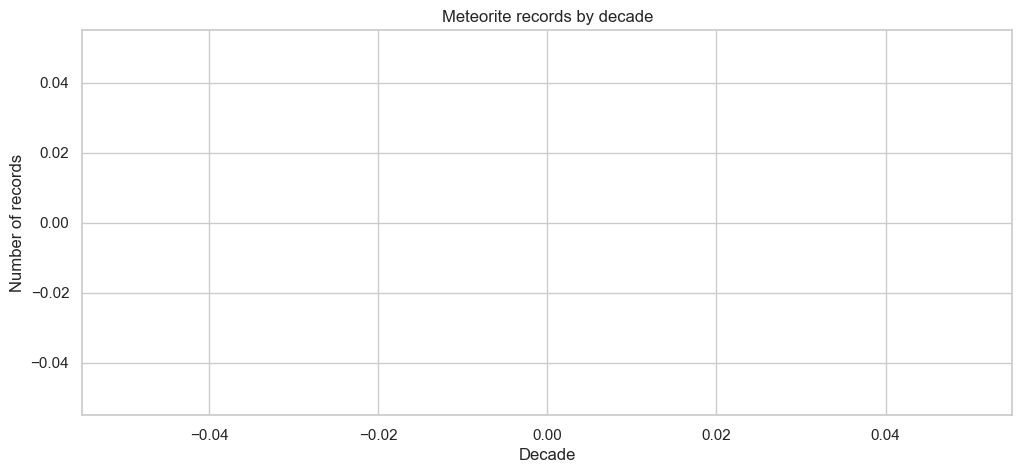

In [57]:


# Group by decade
decade_counts = clean.groupby('decade').size().reset_index(name='count').sort_values('decade')
print(decade_counts)


print('Meteorite counts by decade (sample):')
display(decade_counts.head(15))

# Plot discoveries per decade
plt.figure(figsize=(12,5))
plt.plot(decade_counts['decade'].fillna(0), decade_counts['count'])
plt.title('Meteorite records by decade')
plt.xlabel('Decade')
plt.ylabel('Number of records')
plt.grid(True)
plt.show()


In [58]:
# NumPy operations on mass_kg
mass_arr = clean['mass_kg'].dropna().to_numpy()
print('N (non-NaN masses):', mass_arr.size)
if mass_arr.size>0:
    mean = mass_arr.mean()
    median = np.median(mass_arr)
    std = mass_arr.std()
    total = mass_arr.sum()
    maximum = mass_arr.max()
    print(f'Mean (kg): {mean:.4f}')
    print(f'Median (kg): {median:.4f}')
    print(f'Std dev (kg): {std:.4f}')
    print(f'Sum (kg): {total:.2f}')
    print(f'Max (kg): {maximum:.2f}')
else:
    print('No mass values available for NumPy operations.')


N (non-NaN masses): 0
No mass values available for NumPy operations.


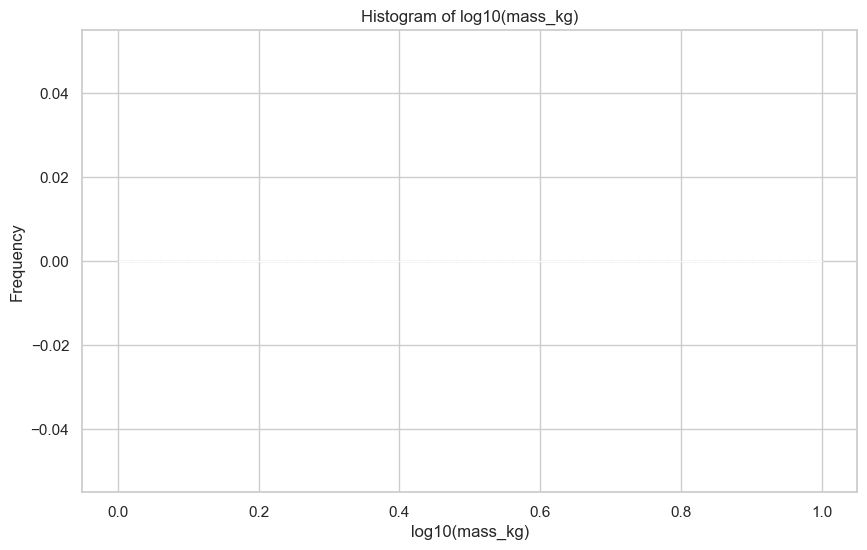

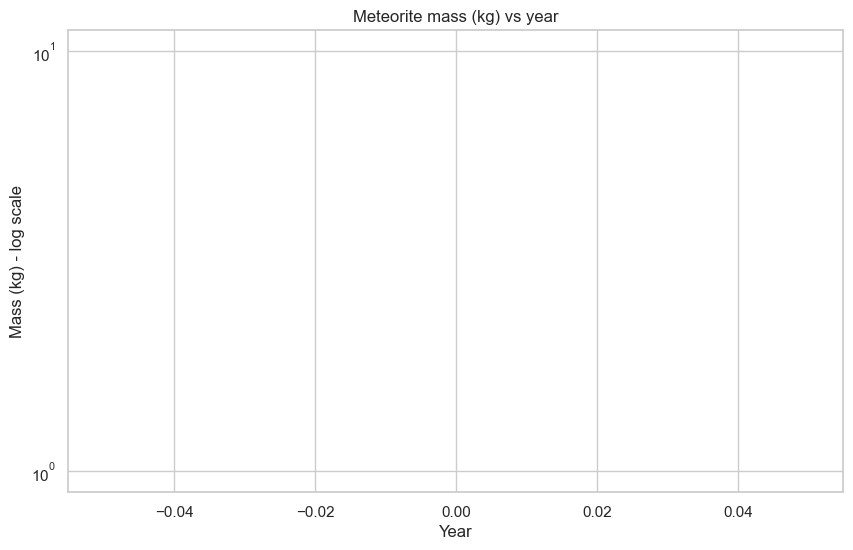

KeyError: 'Fall'

<Figure size 1000x600 with 0 Axes>

In [61]:
# Visualizations (4 plots)
# 1) Histogram of mass (log scale)
plt.figure()
plt.hist(np.log10(clean['mass_kg'].dropna()+1e-9), bins=50)
plt.title('Histogram of log10(mass_kg)')
plt.xlabel('log10(mass_kg)')
plt.ylabel('Frequency')
plt.show()

# 2) Scatter: mass vs year
plt.figure()
plt.scatter(clean['year'], clean['mass_kg'], alpha=0.5)
plt.yscale('log')
plt.title('Meteorite mass (kg) vs year')
plt.xlabel('Year')
plt.ylabel('Mass (kg) - log scale')
plt.show()



# 4) Counts by fall/found (bar)
if 'fall' in clean.columns:
    plt.figure()
    clean['Fall'].value_counts().plot(kind='bar')
    plt.title('Fell vs Found')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.show()
else:
    print('No fall/found column to plot.')


In [46]:
import pandas as pd

df = pd.read_csv('meteorite_landings.csv')




# Print the exact column names
print("COLUMNS IN DATASET:")
print(df.columns.tolist())

# Peek at first few rows
print("\nHEAD OF DATASET:")
print(df.head())

# Check raw columns
print(df.columns)

# Normalize names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'mass (g)': 'mass_g'}, inplace=True)

# Check after rename
print(df[['mass', 'year']].head())

# Convert year
df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year

# Drop rows missing both mass and coords
df = df.dropna(subset=['year', 'mass', 'reclat', 'reclong'])

# Convert mass to kg
df['mass_kg'] = df['mass_g'] / 1000

# Filter outliers
df = df[(df['mass_kg'] > 0) & (df['year'] > 860) & (df['year'] < 2026)]

# Check size of final dataset
print(df.shape)


COLUMNS IN DATASET:
['Name', 'ID', 'NameType', 'Classification', 'Mass', 'Fall', 'Year', 'Coordinates']

HEAD OF DATASET:
       Name   ID NameType Classification                       Mass  Fall  \
0    Aachen    1    Valid             L5      Quantity[21, "Grams"]  Fell   
1    Aarhus    2    Valid             H6     Quantity[720, "Grams"]  Fell   
2      Abee    6    Valid            EH4  Quantity[107000, "Grams"]  Fell   
3  Acapulco   10    Valid    Acapulcoite    Quantity[1914, "Grams"]  Fell   
4   Achiras  370    Valid             L6     Quantity[780, "Grams"]  Fell   

                                           Year  \
0  DateObject[{1880}, "Year", "Gregorian", -5.]   
1  DateObject[{1951}, "Year", "Gregorian", -5.]   
2  DateObject[{1952}, "Year", "Gregorian", -5.]   
3  DateObject[{1976}, "Year", "Gregorian", -5.]   
4  DateObject[{1902}, "Year", "Gregorian", -5.]   

                         Coordinates  
0     GeoPosition[{50.775, 6.08333}]  
1  GeoPosition[{56.18333, 10.2

C:\Users\jaush\AppData\Local\Temp\ipykernel_20312\3001144131.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['year'] = pd.to_datetime(df['year'], errors='coerce').dt.year


KeyError: ['reclat', 'reclong']

In [43]:
# Bonus: Interactive map with Folium (optional)
try:
    import folium
    have_folium = True
except Exception:
    have_folium = False

if have_folium:
    m = folium.Map(location=[0,0], zoom_start=2)
    sample = valid_geo.sample(min(1000, len(valid_geo)), random_state=1)
    for _, row in sample.iterrows():
        folium.CircleMarker(location=[row['lat'], row['lon']],
                            radius=max(2, min(15, (row['mass_kg'] or 0)**0.3)),
                            popup=f"{row.get('name','')} | {row.get('mass_kg', '')} kg | {row.get('year_parsed','')}",
                            fill=True).add_to(m)
    m.save('meteorite_map.html')
    print('Saved interactive Folium map to /mnt/data/meteorite_map.html')
else:
    print('Folium not installed in this environment. To create an interactive map locally, install folium and run the above block.')


Saved interactive Folium map to /mnt/data/meteorite_map.html


## Conclusions (final bullet summary)

- Clean the `year` field carefully — many entries are full datetimes; parse to integer year.
- Mass is highly skewed: a few very large meteorites dominate mean; use median and log-scale plots.
- Geographic records are plentiful but have missing coordinates — filter and validate lat/lon ranges.
- Fell vs Found: most records are 'Found' (people find meteorites later), but 'Fell' entries often have better temporal precision.
- Decade trends often reflect reporting and collection effort increases rather than actual fall rate changes; be careful interpreting raw counts.

---

### Files produced by this notebook (if run fully):
- An interactive map: `/mnt/data/meteorite_map.html` (if folium is available and run)


---

**How to use this notebook**: run cells top-to-bottom. If internet is blocked, download `y77d-th95.csv` manually from NASA Data Portal and rename it to `meteorite_landings.csv` next to this notebook before running.